# Perform 2-protein mass tethering analysis
If a protein is in a complex or as a PTM, it can show up as 2 different masses. This notebook analyses both masses at the same time to give a comprehensive picture of labeling. Caveats: there can be collisions between your protein masses and expected adducts / caps. 
- https://pubmed.ncbi.nlm.nih.gov/28945980/
- match PLP pipeline
- extend to multiple labeling
- visualize plate maps and %BPI curves
- depending on system, this analysis is ~10x faster than pipeline pilot

In [23]:
import os
import pandas as pd
import numpy as np
import logging
import sys
sys.path.append('/Users/apaulson/repos/data-proc')
import plate_maps as pm
sys.path.append('/Users/apaulson/repos/smdc_process_data/process_data')
import tethering_analysis as ta

%config Completer.use_jedi=False
logging.basicConfig(level=logging.INFO)
import importlib


In [24]:
barcodes=[
"SMDC-MPHORE-384-1-02-Eco1",
"SMDC-MPHORE-384-2-02-Eco1",
"SMDC-MPHORE-384-3-02-Eco1",
"SMDC-MPHORE-384-4-02-Eco1",
"SMDC-MPHORE-384-5-02-Eco1",
"SMDC-MPHORE-384-6-01-Eco1",
"SMDC-MPHORE-384-7-01-Eco1",
"SMDC-MPHORE-384-8-02-Eco1"
]

In [ ]:
for barcode in barcodes[4:5]:
    # # DATA INPUT # #
    # # --------------------------------------- # #
    HA_ID=2766
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    # barcode=barcodes[1]
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    pmirm=False # protein mass is reacted mass
    cmirm=True # cap mass is reacted mass
    rmirm=True # reductant mass is reacted mass
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    scan_range = 10
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    assay_class='HTS'
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    masses=[65036, 65215]
    # masses=None
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    infile=f"/example/{barcode}.rpt"
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    outdir=f"./{HA_ID}_tethering_analysis_2masses"
    # # --------------------------------------- # #

    df=ta.extract_rpt_data(infile, outdir=outdir)
    addcaps, masses, site_count=ta.calculate_adduct_and_cap_ranges(HA_ID, barcode, pmirm=pmirm, cmirm=cmirm, rmirm=rmirm, scan_range=scan_range, masses=masses)
    df=ta.analyze_rpt_data(df, addcaps, masses, site_count, scan_range, outdir=outdir)

    dfm=ta.prepare_for_plotting(df, addcaps, barcode)
    dfm=dfm.sort_values(['Row','Col',])
    dfm.to_csv(os.path.join(outdir, f'{barcode}_2masses_raw_data.csv'))

    map=pm.draw_plate_heatmap(barcode=barcode, df=dfm[dfm.protein_mass==masses[0]], wells='Well', values='percentlabeled', labels='hmlab', 
                              center=None, vmin=None, vmax=None, width=25, outdir=os.path.join(outdir, 'heatmaps'))

/Volumes/Shared/SMDC-users/Markella/1.1433 project/HiTS_Upload/tethering/toload/20251107/2766/20251107/SMDC-MPHORE-384-5-02-Eco1.rpt


INFO:root:Adduct mass is not defined for 64 rows.
INFO:root:Adduct mass is not defined for 64 rows.
INFO:root:Analyzing data for 627 samples.
/Users/apaulson/repos/data-proc/plate_maps.py:155: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plabels=plabels.fillna(-99).astype(str).replace('-99','', regex=True)


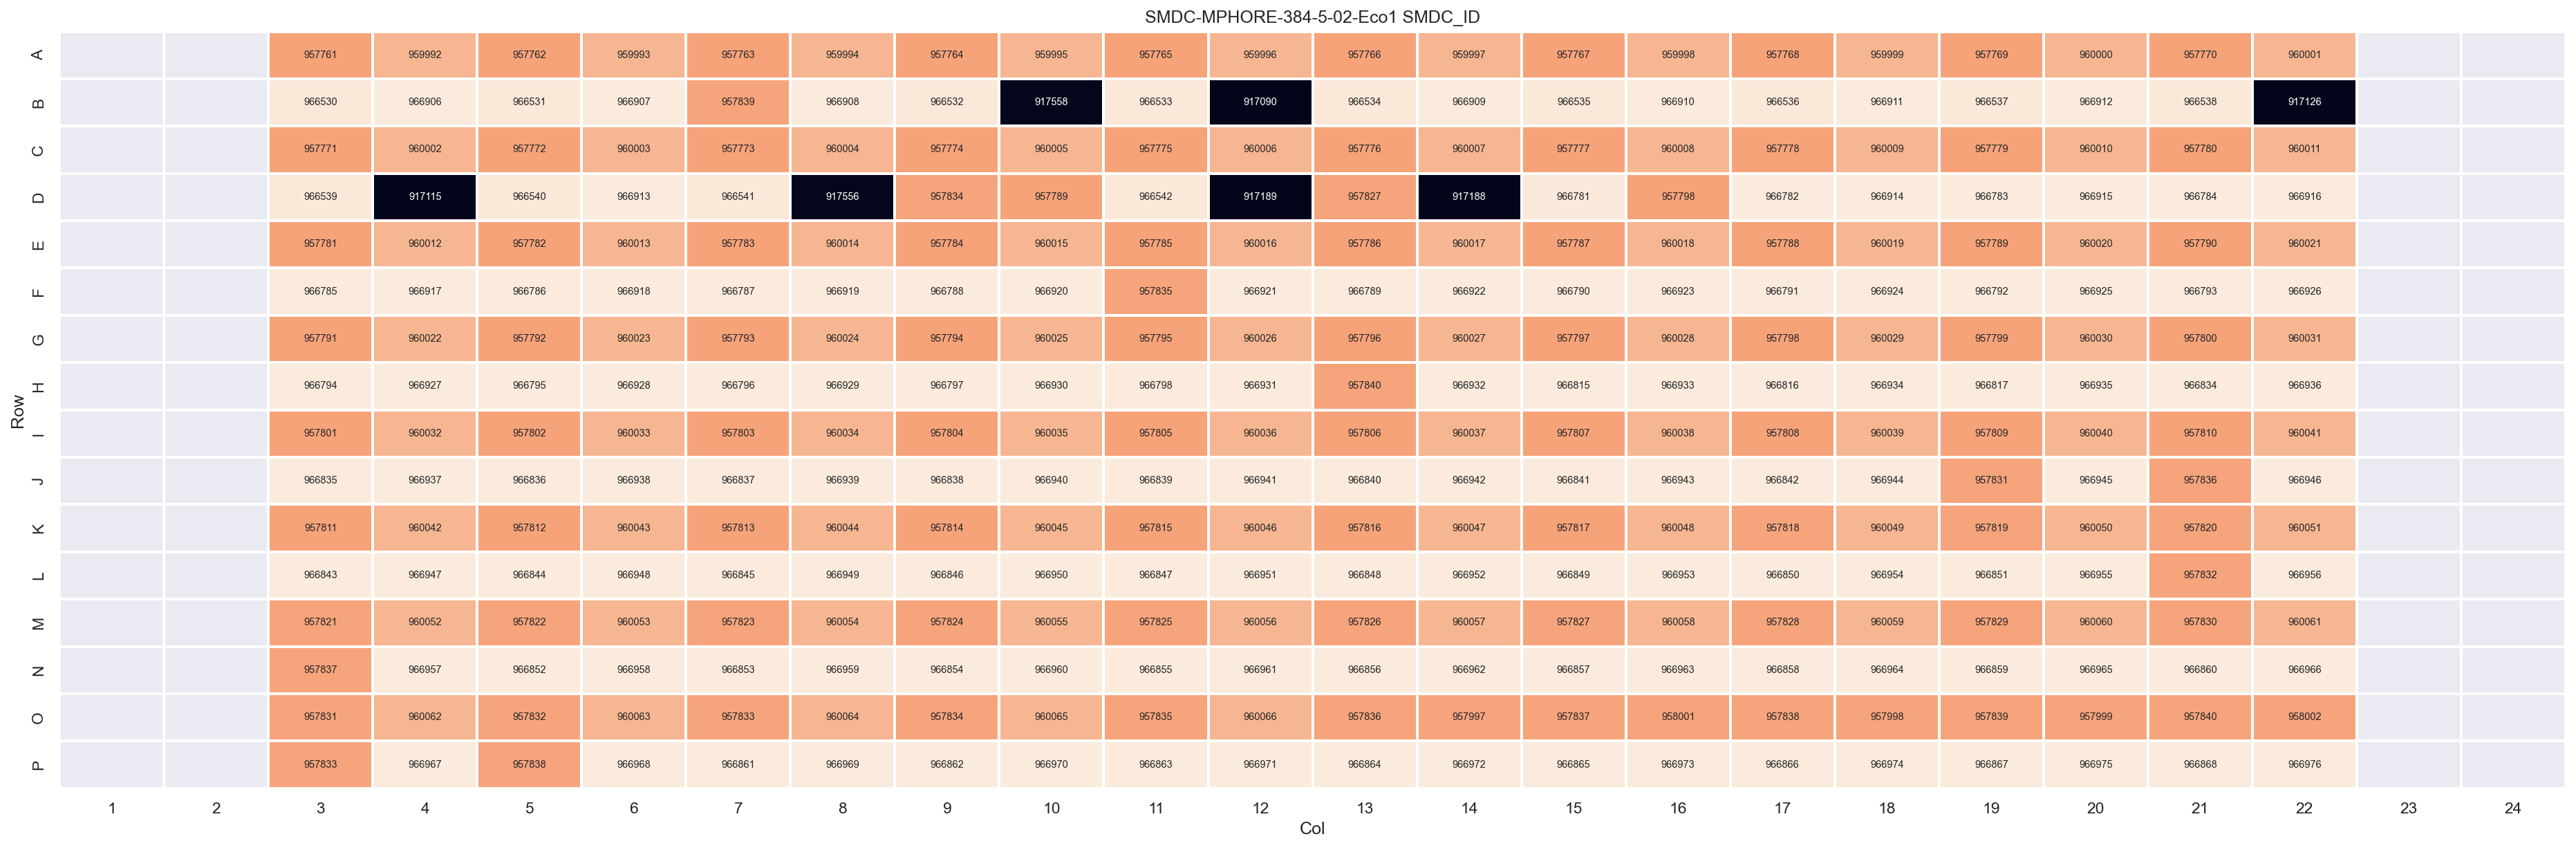

In [26]:
map=pm.draw_plate_heatmap(barcode=barcode)

In [27]:
# # plot all
# importlib.reload(ta)
# for smdc in dfm.SMDC_ID.unique():
#   ta.plot_bpi(dfm, smdc, scan_range, outdir=outdir)

966930.0


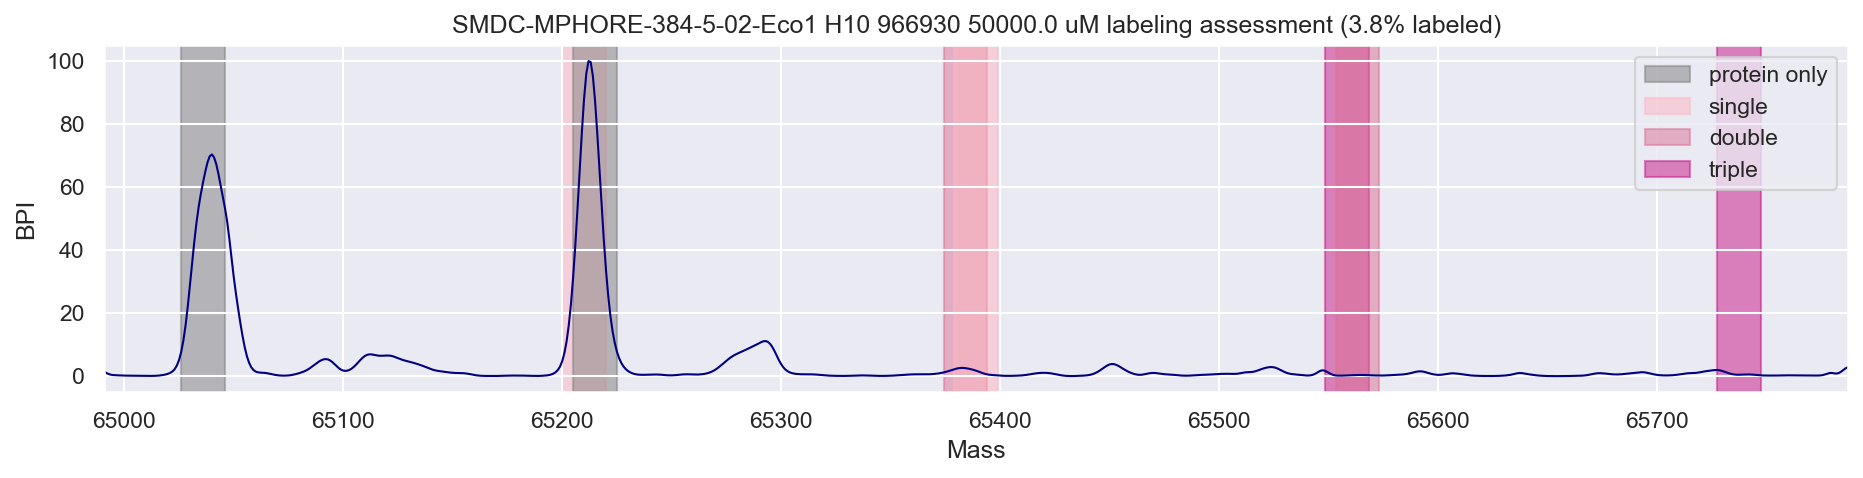

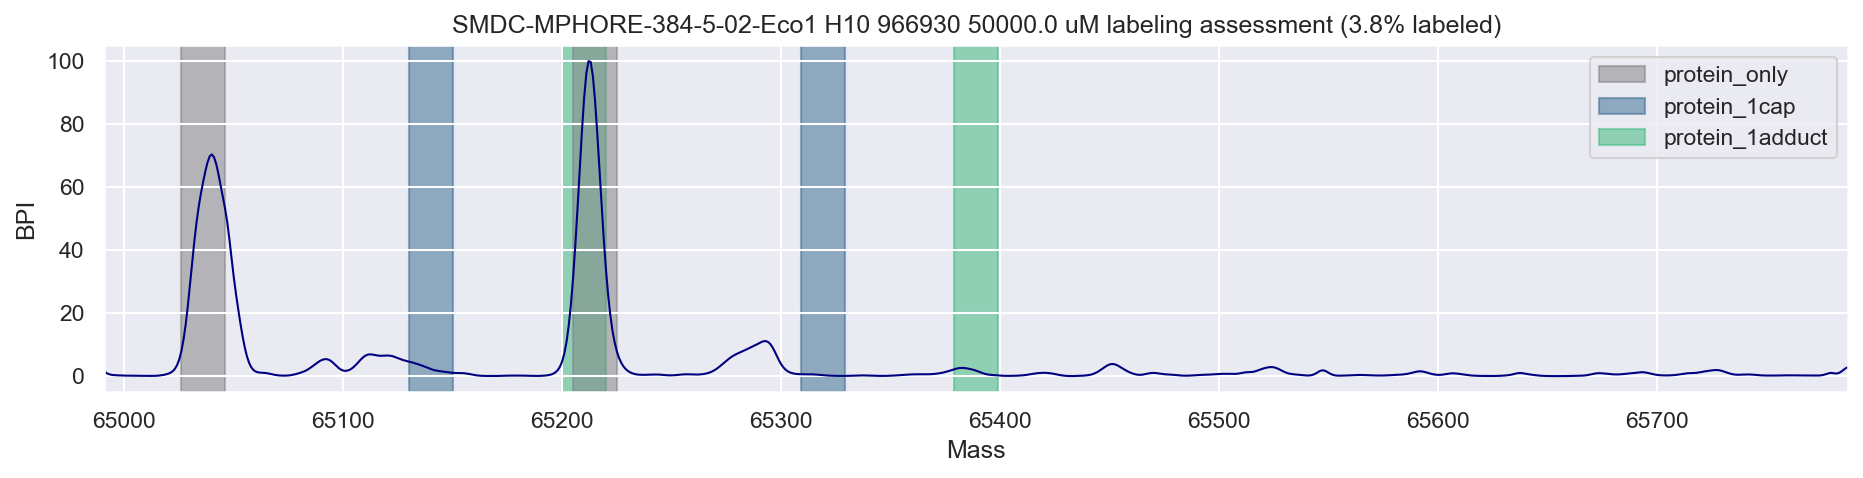

In [28]:
importlib.reload(ta)
# %debug
smdc=dfm[dfm.Well=='H10'].SMDC_ID.iloc[0]
print(smdc)
ta.plot_bpi(dfm, smdc, scan_range, outdir=outdir, save=False)